<a href="https://colab.research.google.com/github/ZahirulNiloyCodes/CyberDataset_NLP/blob/main/Cyber_Dataset_nlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data Loading(NLP Dataset)**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_excel("/content/phishing_nlp_dataset.xlsx")

In [ ]:
df.head(5)

,Corpus,Labels
0,"You have (1) package waiting, ready for delive...",NaN
1,We were unable to deliver your package as ther...,NaN
2,We are here to inform you that we need address...,NaN
3,You have (1) message from us. Click below to o...,NaN
4,You have (1) package awaiting delivery. Use yo...,NaN


# **Categorising into text and Classification**

In [ ]:
row_string=None
text_list=[]
class_list=[]
for content_column in df.iloc[:,0]:
  row_string=str(content_column)
  if '\t' in row_string:
    string=row_string.split('\t')
    text_list.append(string[0])
    class_list.append(string[-1])

df=pd.DataFrame({
    'Text_Data':text_list,
    'Label':class_list
})

In [ ]:
df.head(5)

,Text_Data,Label
0,"You have (1) package waiting, ready for delive...",Phishing
1,We were unable to deliver your package as ther...,Phishing
2,We are here to inform you that we need address...,Phishing
3,You have (1) message from us. Click below to o...,Phishing
4,You have (1) package awaiting delivery. Use yo...,Phishing


In [ ]:
df['Label'].value_counts()

,count
Label,
NOT-Malicious General Class,171
Phishing,114
Scareware,100
Baiting,80
Malware,78
Pretexting,78


In [ ]:
df['Label'].value_counts().sum()

np.int64(621)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 621 entries, 0 to 620
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Text_Data  621 non-null    object
 1   Label      621 non-null    object
dtypes: object(2)
memory usage: 9.8+ KB


In [ ]:
df.describe()

,Text_Data,Label
count,621,621
unique,606,6
top,You have won a cash prize. Confirm your identi...,NOT-Malicious General Class
freq,4,171


# **Exploratory Data Analysis**

In [ ]:
import seaborn as sns

 **Class Imbalance Check**

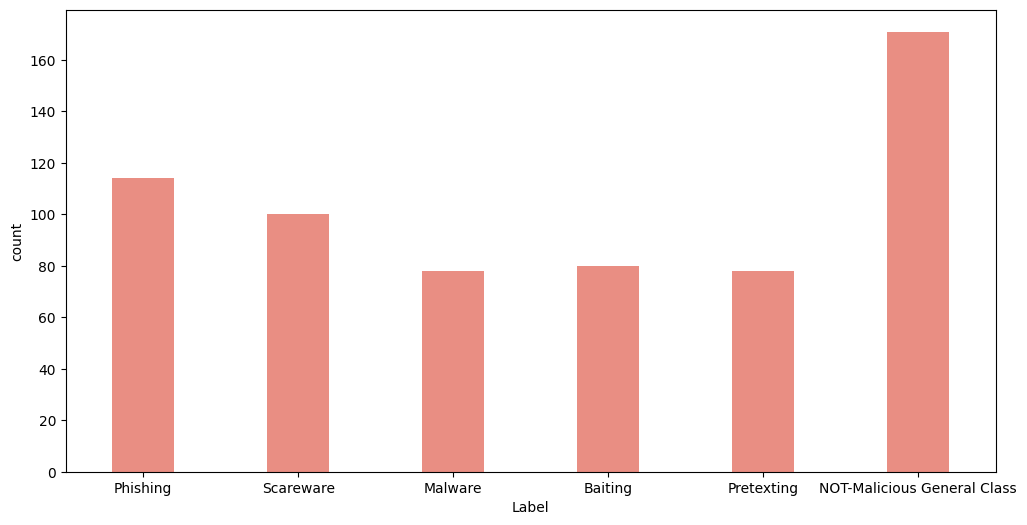

In [ ]:
plt.figure(figsize=(12,6))
sns.countplot(data=df,x='Label',width=0.4,color='Salmon')
plt.show()

**Finding Word Count**

In [ ]:
def get_word_count(text):
  string=str(text)
  words=string.split()
  return len(words)
words_list=[]
for string in df.iloc[:,0]:
  count=get_word_count(string)
  words_list.append(count)
df=pd.DataFrame({
    'Text_Data':text_list,
    'Label':class_list,
    'Word-Count':words_list
})
df.head(5)

,Text_Data,Label,Word-Count
0,"You have (1) package waiting, ready for delive...",Phishing,17
1,We were unable to deliver your package as ther...,Phishing,22
2,We are here to inform you that we need address...,Phishing,17
3,You have (1) message from us. Click below to o...,Phishing,11
4,You have (1) package awaiting delivery. Use yo...,Phishing,16


**Label Against Word-Count**

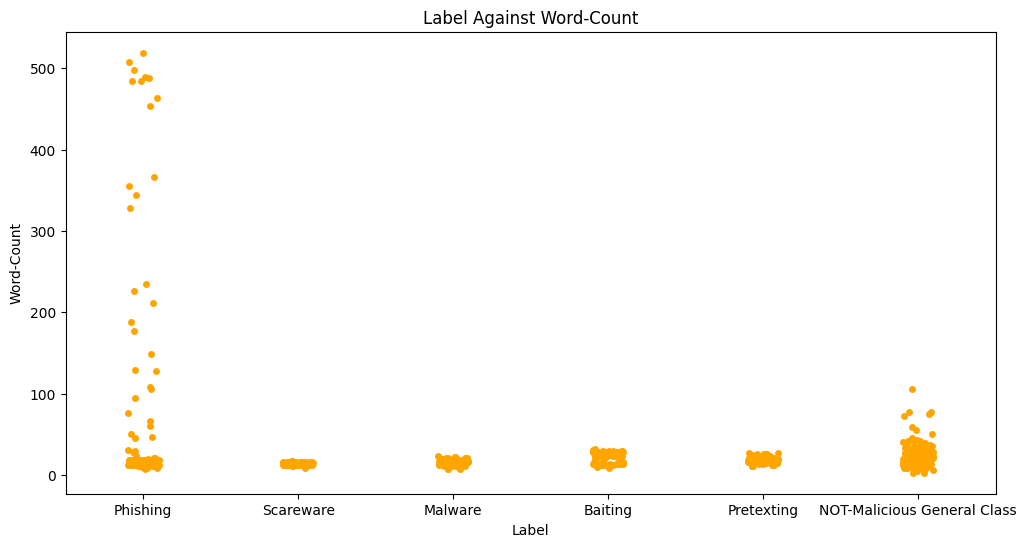

In [ ]:
plt.figure(figsize=(12,6))
sns.stripplot(data=df,x='Label',y='Word-Count',color='Orange')
plt.title("Label Against Word-Count")
plt.show()

**Link Trap Finding**

In [ ]:
list1=[]
i=0
for string in df.iloc[:,0]:
  if 'http'in string:
    list1.append(df.iloc[i,1])
  elif '$' in string:
    list1.append(df.iloc[i,1])
  i+=1
print(list1)

['Phishing', 'Phishing', 'Phishing', 'Phishing', 'Phishing', 'Phishing', 'Phishing', 'Phishing', 'Phishing', 'Phishing', 'Phishing', 'Phishing', 'Phishing', 'Phishing', 'Phishing', 'Baiting', 'Baiting', 'Phishing', 'Phishing', 'Phishing', 'Phishing']


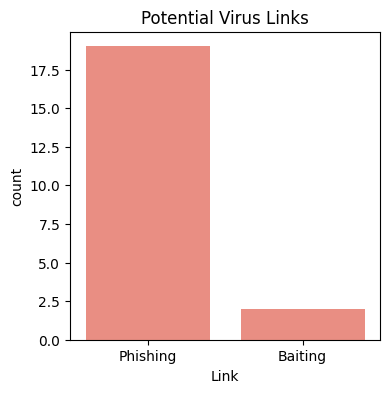

In [ ]:
plt.figure(figsize=(4,4))
linkdf=pd.DataFrame({'Link':list1})
sns.countplot(data=linkdf,x='Link',color="Salmon")
plt.title("Potential Virus Links")
plt.show()